# Chapter 4
# Introduction to Correlation and Latent Variables

## Introduction

**Correlation**, is a measure of **statistical dependence** between two variables, and an important summary statistic. However, it is hard to over-emphasize the point that **correlation is not causation**! Variables can be highly correlated for any number of reasons, none of which imply a causal relationship. One of several pitfalls in interpretation of correlation, regardless of method used, is that these measures are all symmetric. This means that even if a causal relationship exists, one cannot tell which variable is the causal one. The correlation measure is the same!

Nonetheless, used correctly, correlation can be a useful exploratory data analysis tool. Finding some kind of dependency between variables can lead to significant insight.  At the same time, one must keep in mind the several limitations of these methods and not over-interpret the results.When trying to understand relationships between variables, it is worth the effort to think carefully and ask the question, does this relationship make sense?    

A related problem is possible effects from **latent variables**. Latent variables are variables that are not directly observed. In other words, such variables are said to be 'hidden', hence the use of the term latent. The effect of a latent variable can lead on to think there is a strong dependency between two variables, when in fact, the depenency is with the same latent variable. This situation is known as a **confounding effect**. The presence of confounding latent variables can lead to seriously incorrect inferences.      

In this chapter, we will:  
- Apply three measures of statistical dependence or correlation. Each of these measures has somewhat different properties.   
- Examine the effects of a latent confounding variable.   
- Use common variable transformations to better understand the relationship between variables.   

## Pearson's correlation coefficient

In this section, we will use the **Pearson correlation coefficient**, originally published by Karl Pearson [@Pearson_1895].  According to research by Steven Stigler [@Stigler_1989] Frances Galton likely used this method as early as 1877. 

The Pearson correlation coefficient is the most widely used measure of statistical dependency. When people use the term 'correlation', they often mean Pearson correlation. The Pearson correlation coefficient, between two vectors $\mathbf{x}$ and $\mathbf{y}$, can be writen:   

$$
\rho_{\mathbf{x}, \mathbf{y}} = \frac{\sum_{i=1}^n (x_i - \bar{\mathbf{x}})(y_i - \bar{\mathbf{y}})}{\sigma_{\mathbf{x}} \sigma_{\mathbf{y}}}
$$   

Where;    
$\bar{\mathbf{x}} =$ the mean of the vector $\mathbf{x}$,   
$\bar{\mathbf{y}} =$ the mean of the vector $\mathbf{y}$,  
$\sigma_{\mathbf{x}} =$ the variance of the vector $\mathbf{x}$,   
$\sigma_{\mathbf{y}} =$ the variance of the vector $\mathbf{y}$.   

Notice that the Pearson correlation is normalized by the product of the variances of the two vectors. This means that the value must be in the range, $-1 \ge \rho_{\mathbf{x}, \mathbf{y}} \ge 1$. To understand the behavior of this statistic, it helps to keep some particular values in mind:     
- $\rho_{\mathbf{x}, \mathbf{y}} = 1$, the vectors are perfectly correlated, meaning the relative change in one exactly corresponds to the same relative change in the other. In other words, the vectors are parallel.        
- $\rho_{\mathbf{x}, \mathbf{y}} = 0$, the vectors are uncorrelated, meaning there is no relationship between the two vectors. In other words, the vectors are **orthogonal**.    
- $\rho_{\mathbf{x}, \mathbf{y}} = -1$, the vectors are perfectly anti-correlated, meaning a relative change in one exactly corresponds to the same relative change in the other with the opposite sign.   

Another important property of Pearson correlation is that it is linear in the value pairs $(x_i,y_i)$. This property has several implications. For example, as the value of one variable changes, the other will change by a proportion of the correlation coefficient. Further, the value of the correlation coefficient can be significantly affected by outliers in the values of the variables.  

We will have more to say about the statistical properties of Pearson correlation in Part 3 of this book.  

### An example

We will use an example to illustrate the pitfalls of interpreting correlation. @Messerli reported a high correlation between chocolate consumption per person in a country and the number of people per ten million in that country who win Nobel Prizes. Messerli states that there may be some improvement in cognitive function from compounds known as flavonoids contained in chocolate. 

Messerli's work was widely discussed in the popular press. Many people would like to think that eating more chocolate increases their chances of winning a Nobel Prize. But, does this relationship really make sense for an entire population of a country? This conclusion has been challenged by a number of other authors, including @Maurage_etal.    

Let's investigate this claim ourselves. As a first step, the required packages are imported and the data set is loaded and printed. 

In [4]:
import pandas as pd
import numpy as np
import io
from itertools import combinations
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

Nobel_chocolate = pd.read_csv('../data/nobel-chocolate.csv', thousands=',')
print(Nobel_chocolate)


           Country  Laureates10_million  Chocolate  Nobellaureates  Population
0      Switzerland               32.771        8.8              28     8544034
1           Sweden               30.052        8.1              30     9982709
2          Austria               25.138        7.9              22     8751820
3          Denmark               24.329        7.9              14     5754356
4           Norway               24.284        6.6              13     5353363
5          Ireland               14.572        5.8               7     4803748
6          Germany               13.245        5.7             109    82293457
7    United States               11.721        5.6             383   326766748
8           France               10.664        5.4              70    65233271
9          Finland                9.021        5.0               5     5542517
10         Belgium                8.697        4.9              10    11498519
11     New Zealand                6.316        4.9  

The table printed above shows data for the 18 countries with Nobel laureates. Notice at the bottom of the table there are three countries with low chocolate consumption and low numbers of Nobel laureates per ten million people. In particular, China has low chocolate consumption and a low number of Nobel laureates per ten million. The latter can be attributed to China's large population, rather than a small number of prizes. 

Only 18 countries have ever had Nobel laureates. These countries are predominantly in Western Europe, plus the United States. There is an unmistakable geographic bias in the historical award of Nobel Prizes.  

Next, we use the Pandas [`corr`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) method to compute the correlations between the two variables of interest.  


In [5]:
Nobel_chocolate.loc[:, ['Laureates10_million', 'Chocolate']].corr()

,Laureates10_million,Chocolate
Laureates10_million,1.000000,0.878087
Chocolate,0.878087,1.000000


The result is a **correlation matrix** showing all possible correlations between the variables which is interpreted as follows: 
- On the diagonal is the correlation of each variable with itself. These correlations are always 1.0.
- The off-diagonal terms are the correlation coefficients between the pairs of variables. The values in the upper and lower off-diagonal terms are symmetric about the diagonal for real-valued variables. The correlation between chocolate consumption and Nobel Prizes is indeed rather high. 

When addressing a problem like this, it is always a good idea to explore the relationships visually. The code below creates a scatter plot of these data. **Scatter plots** are both widely used and extremely useful, and should be familiar to most readers. The code below uses the Seaborn [`scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) function to create the desired display. 


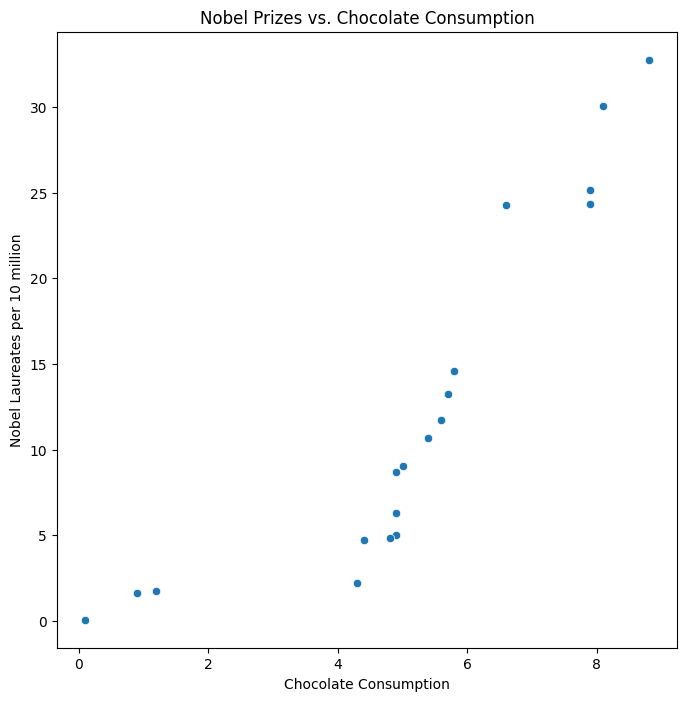

In [6]:
plt.figure(figsize=(8,8)) # Set the figure size
ax = sns.scatterplot(x='Chocolate', y='Laureates10_million', data=Nobel_chocolate)
ax.set_xlabel('Chocolate Consumption');
ax.set_ylabel('Nobel Laureates per 10 million');
ax.set_title('Nobel Prizes vs. Chocolate Consumption');

There is indeed a strong trend in chocolate consumption vs. Nobel Prizes. However, this does not prove any dependency on one variable or the other. An alternative hypothesis could be that people engaged in intellectual pursuits have a stronger craving for chocolate. Given that correlation is a symmetric measure, there is no way to tell which might be the causal variable from observational data. Nor, can we rule out the lack of a causal relationship.   

Notice also that there are three outliers in the lower left corner of the plot. These are the three outlier countries already noted. 

## Latent variables

It is often the case that there are **latent or hidden variables** in **observational data**. Statisticians have recognized the importance of latent variables when interpreting data for more than a century, including @Pearson_1899.

Our example is based on observation data. Observational data are collected by observing some type of system that cannot be manipulated. In this case, people in various countries eating chocolate and winning Nobel Prizes. There is nothing we can do to change either of these outcomes. Observational data is in contrast to **experimental data**, wherein the experimenter deliberately manipulates the system being observed. We will have more to say about experimental data in Part 3 of this book.   

Continuing with our example, could there be other variables that might explain the number of Nobel laureates per ten million a country might produce? The answer is, quite likely yes. There are several candidates, such as GDP per person or education levels in a country. The code below loads a data set of Gross Domestic Product (GDP) for the 18 countries taken from the [World Bank Open Data](https://data.worldbank.org/).  


In [7]:
GDP = pd.read_csv('../data/GDP_Country.csv')
print(GDP)

           Country  GDP_billions
0      Switzerland           679
1           Sweden           538
2          Austria           417
3          Denmark           325
4           Norway           399
5          Ireland           334
6          Germany          3677
7    United States         19390
8           France          2583
9          Finland           252
10         Belgium           493
11     New Zealand           206
12          Poland           525
13       Australia          1323
14  Czech Republic           216
15           Japan          4872
16    South Africa           349
17          Russia          1578
18           China         12240


The code below performs the following operations:
1. Left joins the two tables with the `country` column as key, using the Pandas [merge](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html) method.   
2. Standardizes the GDP to thousands per person. 


In [8]:
Nobel_chocolate = Nobel_chocolate.merge(right=GDP, how='left', left_on='Country', right_on='Country')
Nobel_chocolate['GDP_person_thousands'] = 1000000 * np.divide(Nobel_chocolate.GDP_billions, Nobel_chocolate.Population)

Next, the code below computes the correlation matrix of all three variables. 



In [9]:
Nobel_chocolate.loc[:, ['Laureates10_million', 'Chocolate', 'GDP_person_thousands']].corr()

,Laureates10_million,Chocolate,GDP_person_thousands
Laureates10_million,1.000000,0.878087,0.761228
Chocolate,0.878087,1.000000,0.815881
GDP_person_thousands,0.761228,0.815881,1.000000


The high correlation of chocolate consumption and the Nobel laureates per ten million people has already been noted. The correlation between the GDP per person and Nobel laureates is also fairly high. Additionally, the correlation between chocolate consumption and GDP per person is high as well. Is it possible that people in countries with higher GDP can afford to eat more chocolate as well as more likely to win Nobel Prizes?    

> **Exercise 4-1:** There are three variables of interest, Laureates10_million, Chocolate, and GDP_person_thousands. Use the Pandas `describe` method to compute summary statistics for these variables. Based on these statistics, which of these variables shows a high degree of skewness? What bias in the data does this condition highlight?    

In [11]:
## Put your code below  
df = Nobel_chocolate.copy()

df['Laureates10_million'].describe()


count    19.000000
mean     12.155368
std      10.273976
min       0.064000
25%       4.775000
50%       9.021000
75%      19.428000
max      32.771000
Name: Laureates10_million, dtype: float64

> **Answer:**     

> **Exercise 4-2:** To confirm your conclusion from the previous exercise,k create distribution plots of each of the three variables. Do these plots agree with your conclusions from the previous exercises? 

In [ ]:
## Put your code below 









> **Answers:**    

> **Exercise 4-3:** It makes more sense that GDP per person is a significant factor in explaining why people in a country win Nobel prizes. But, before drawing any conclusions you should examine the relationships visually. To do so, make two scatter plots:  a) Nobel Prizes per ten million peoples vs. GDP per ten thousand people. b) Chocolate consumption per person  vs. GDP per ten thousand people. Is it possible that people in countries with higher GDP per person are more likely to both eat chocolate and engage in intellectual pursuits?       

In [ ]:
## Put your code below  
fig,ax = plt.subplots(1,2,figsize=(12,6)) # Set the figure size







> **Answers:**     

## Correlation with Kendall's tau

Pearson's correlation method is not the only way we can measure statistical dependence. A family of correlation methods use **rank statistics**. Ranking is a common procedure in statistics. **Rank values** are assigned by ordering the values of a variable and then assigning an ordered rank to each value. A sequence of ranks is known aa a set of **ordinal numbers**. Correlation methods based on rank are considered **nonparametric** since they are based on ordered rank rather than a model with specific parameters. 

Nonparametric measures of statistical dependence exhibit more robust behavior when there is a nonlinear relationship between the variables. This robustness can also be useful when there are outliers in the variables. 

One such measure of statistical dependence developed by Marice Kendall [@Kendall] is known as the **Kendall's rank correlation coefficient** or **Kendall's tau**. Kendall's tau is based on ranking of pairs of ordered variables. The formula for the Kendal's tau is expressed:  

$$
\tau = \frac{(number\ of\ concordant\ pairs) - (number\ of\ dsconcordant\ pairs)}{{n \choose 2}}
$$

A concordant relationship is defined as follows. The pairs of observations, $(x_i,y_i)$, are ordered by the values of one of the variables. For pairs of the ordered observations, $(x_i,y_i)$ and $(x_j, y_j)$, the relationship is considered **concordant** if $x_i > x_j$ and $y_i > y_j$ or if $x_i < x_j$ and $y_i < y_j$. Otherwise, the relationship is considered discordant.   

The denominator, ${n \choose 2}$, is known as the **Binomial coefficient**. In this case, it is the number of ways 2 of n data pairs can be uniquely ordered. We will have more to say about the Binomial coefficient in Part 2 of this book. 

The code below uses the python `corr` method with the `method` argument set to kendal. 

In [ ]:
Nobel_chocolate.loc[:, ['Laureates10_million', 'Chocolate', 'GDP_person_thousands']].corr(method='kendall')

These values are somewhat different from those computed with the Pearson method. The differences arise from the treatment of the outliers noted in the plot. The correlation between chocolate and Nobel laureates is still the highest.    

# Correlation with Spearman rank correlation   

Another rank-based correlation method is named for statistician Charles Spearman [@Kendall_Stuart]. This method uses direct rank ordering. The pairs of variables, $(x_i,y_i)$, are ordered by the values of one of the variables. Both variables are then converted to rank values or ordinal values. The correlation coefficient is then computed:   

$$
\rho_{\mathbf{xr}, \mathbf{yr}} = \frac{\sum_{i=1}^n (xr_i - \overline{\mathbf{xr}})(yr_i - \overline{\mathbf{yr}})}{\sigma_{\mathbf{xr}} \sigma_{\mathbf{yr}}}
$$

Where,     
$\mathbf{xr}$ are the ordinal numbers of the variable $\mathbf{x}$.     
$\mathbf{yr}$ are the ordinal numbers of the variable $\mathbf{y}$.      

The code below computes the Spearman rank correlation for our example data.


In [ ]:
Nobel_chocolate.loc[:, ['Laureates10_million', 'Chocolate', 'GDP_person_thousands']].corr(method='spearman')

Once again, the correlation coefficients by the Spearmen method are different from those computed by the other methods. 

# Conclusions  

What if any conclusions can be made from these three sets of correlation coefficients? It is clear that the correlation between chocolate consumption and Nobel prizes is the strongest. But, even though it is reasonable to think flavonoids improve cognitive ability, extrapolating to winning a Nobel prize requires more substantiation. There is clearly a relationship between GDP per person and winning Nobel Prizes. There could still be other latent variables, such as levels of educational obtainment in a country which could help explain the chance of winning Nobel Prizes. Finally, we cannot discount the fact that correlation is a symmetric measure. In summary, **correlation cannot be mistaken for causality**. 

# Transformation of the variables

Finding and testing useful transformations of variables is an important component of the EDA process. Here, we will apply a transformation to our running example. A more general approach will be presented in Part 3 of this book.

We also introduce another powerful EDA technique; using a regression line to highlight a relationship between two variables. In particular, the use of curves, such as from polynomials, can show important relationships. In the example, we will skip the mathematical details. The theory and evaluation of polynomial regression models is discussed in Part 4 of this book. 

We examine a number of transformations of the variables in the Nobel laureate data. A simple criterion is used for evaluating these transformations if the relationship is a straight line. In Parts 3 and 4 of this book, we will investigate a more sophisticated approach.       

Recalling the plot of chocolate consumption vs. Nobel prizes, we will continue the iterative process of exploring and understanding these data. Notice that the relationship does not seem to approximate a straight line. To confirm this the code in the cell below uses the Seaborn [`lmplot'](https://seaborn.pydata.org/generated/seaborn.lmplot.html) function to make a scatter plot with a second-order polynomial curve overlaid. We will discuss fitting polynomial models in Part 4 of this book. 

> **Programming Note:** Unlike many Seaborn plot functions, the `lmplot` does not return an axis. Instead, a grid object is returned. Therefore, other plot attributes are set by direct calls to Matplotlib functions. We will discuss grid objects in depth in Chapter 5. 


In [ ]:
g = sns.lmplot(x='Chocolate', y='Laureates10_million', order=2, data=Nobel_chocolate)
g.fig.subplots_adjust(top=.9)
plt.xlabel('Chocolate Consumption')
plt.ylabel('Nobel Laureates per 10 million')
plt.title('Nobel Prizes vs. Chocolate Consumption\nwith polynomial fit')

The curve fitting these data is far from straight. In particular, three data points add significant curvature. The shaded area indicates the 95% confidence interval for the curve fit. We will have more to say about this aspect of these plots later in the book.  

Consider the relationships shown above. During EDA, a question to ask is, what type of function best transforms the data to a straight-line relationship? Keep in mind that transformations can be applied to either or both variables. A common choice of transformation is the logarithm. The code below applies the log transformation and plots the result.  


In [ ]:
Nobel_chocolate.loc[:,'log_Laureates10_million'] = np.log(Nobel_chocolate.loc[:,'Laureates10_million'])

g = sns.lmplot(x='Chocolate', y='log_Laureates10_million', order=2, data=Nobel_chocolate)
g.fig.subplots_adjust(top=.9)
plt.xlabel('Chocolate Consumption')
plt.ylabel('Log Nobel Laureates per 10 million')
plt.title('Log Nobel Prizes vs. Chocolate Consumption\nwith polynomial fit')

The polynomial curve is much closer to a straight line. But, the curve seems to be pulled down on the left by the outlier, China? What if this outlier was eliminated from the data. How would this change the polynomial fit. The code in the cell below uses the Pandas `iloc` method to remove the outlier and create a new plot. 



In [ ]:
g = sns.lmplot(x='Chocolate', y='log_Laureates10_million', order=2, data=Nobel_chocolate.iloc[:-1,:])
g.fig.subplots_adjust(top=.9)
plt.xlabel('Chocolate Consumption')
plt.ylabel('Log Nobel Laureates per 10 million')
plt.title('Log Nobel Prizes vs. Chocolate Consumption\nwith polynomial fit, no outlier')

The relationship is now very close to a straight line. After several iterations of data exploration we found the log transformation was successful. Even with the removal of one outlier, it is evident that a curved line would give a better fit to the bulk of the data. Despite the apparently good fit, this analysis does not imply a causal relationship!     

> **Exercise 4-4:** As has been stated several times, EDA is an iterative process. In the forgoing example, the number of Nobel laureates per 10 million was log transformed. Is it possible that transforming the chocolate consumption variable is a better idea? To test this idea, create a chart with the log of per person chocolate consumption on the horizontal axis and Nobel laureates per 10 million on the vertical axis. Include a polynomial curve. Remove the outlier. Does this transformation success in creating a straight line relationship? How does this fit compare to the plot of log of Nobel laureates vs. personal chocolate consumption?     

In [ ]:
## Put your code below   







> **Answer:**     

> **Exercise 4-5:** This exercise continues the iterative process of exploring the data set. In a previous exercise you created a chart of Nobel laureates vs GDP. It may be the case that transforming GDP gives a fit closer to a straight line. To find out create several plots with a straight line regression using `regplot`, excluding the single outlier:     
> 1. GDP per thousand person on the horizontal axis vs. log Nobel Prizes per 10 million on the vertical axis.    
> 2. log GDP per thousand person on the horizontal axis vs. Nobel Prizes per 10 million on the vertical axis.     
> 3. log GDP per thousand person on the horizontal axis vs. log Nobel Prizes per 10 million on the vertical axis.   

In [ ]:
## Put your code below   












> Provide short answers to the following questions:      
> 1. Which of these plots appears to give the straightest line relationship with the most consisted dispersion around the fitted line?      
> 2. Does this relationship seem more likely to be reasonable than a relationship between chocolate consumption and laureates?           
> 3. What does the process followed to find this relationship tell you about exploring relationships in data?

> **Answers:** 
> 1.            
> 2.     
> 3.              

> **Exercise 4-6:** Now, you will repeat the previous exercise with the outlier (the last row of the data frame) removed. Which relationship appears to give the straightest line and how does this result compare to those obtained with the outlier included? 

In [ ]:
## Put your code below 








> **Answer:**  

## Summary    

In this chapter we have discussed the use and misuse of correlation. Specifically:

- Correlation does not demonstrate causation. Even in cases of a causal relationship, correlation is symmetric between variables.
- Latent variables can confound analysis. Introduction of a new, previously latent, variable into a data set can result in reinterpretation of relationships between other variables. 
- Transformation of variables is often an important step in understanding the relationship between them.  


##### Copyright 2020, 2023 Stephen F Elston. All rights reserved.   


### Bibliography